## Data Wrangling

In [105]:
import pandas as pd

data_file = '/Users/kaleee/project-2026/datathon-ui-2026/data/raw_data.csv'
df = pd.read_csv(data_file)


#### Summary and Basic Info of Data



In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80472 entries, 0 to 80471
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Judul    80472 non-null  object
 1   Waktu    80472 non-null  object
 2   Link     80472 non-null  object
 3   Content  80463 non-null  object
 4   tag1     78023 non-null  object
 5   tag2     77612 non-null  object
 6   tag3     71602 non-null  object
 7   tag4     56856 non-null  object
 8   tag5     35633 non-null  object
 9   source   80472 non-null  object
dtypes: object(10)
memory usage: 6.1+ MB


In [107]:
df.describe()

,Judul,Waktu,Link,Content,tag1,tag2,tag3,tag4,tag5,source
count,80472,80472,80472,80463,78023,77612,71602,56856,35633,80472
unique,67168,26970,67381,67367,18490,24482,26226,24944,18463,3
top,5 Berita Terpopuler Internasional Hari Ini,26 November 2024,https://news.detik.com/berita/d-7775758/kennet...,"Baca berita dengan sedikit iklan, klik di sin...",Jakarta,jabodetabek,jabodetabek,jabodetabek,jabodetabek,kompas
freq,7,149,4,5,865,488,915,951,557,35449


In [108]:
df.head()

,Judul,Waktu,Link,Content,tag1,tag2,tag3,tag4,tag5,source
0,"Viral Isu PHK Buruh Gudang Garam, Said Iqbal: ...",6 September 2025,https://nasional.kompas.com/read/2025/09/06/14...,"JAKARTA, KOMPAS.com – Presiden Konfederasi Se...",Said Iqbal,industri rokok,PT Gudang Garam,PHK massal,phk massal 2025 terbaru,kompas
1,"Gempa M 5,3 Guncang Pulau Doi Maluku Utara","Senin, 12 Agu 2024 21:58 WIB",https://news.detik.com/berita/d-7486691/gempa-...,"Gempa bumi berkekuatan magnitudo (M) 5,3 mengg...",pulau doi,gempa,NaN,NaN,NaN,detik
2,"Toko Emas Palsu di Riau Dibongkar Polisi, Perh...","Rabu, 30 Jul 2025 22:22 WIB",https://news.detik.com/melindungi-tuah-marwah/...,Satreskrim Polres Bengkalis membongkar praktik...,pemalsuan emas,emas palsu,polres bengkalis,polda riau,melindungi tuah marwah,detik
3,Minyakita Tak Sesuai Ukuran juga Ditemukan di ...,"Senin, 10 Mar 2025 23:15 WIB",https://news.detik.com/berita/d-7816829/minyak...,Polisi mendatangi salah satu gudang Minyakita ...,minyakita,kudus,NaN,NaN,NaN,detik
4,"Pimpin LDP, Sanae Takaichi Calon Kuat PM Perem...",4 Oktober 2025 | 14.00 WIB,https://www.tempo.co/internasional/pimpin-ldp-...,"Baca berita dengan sedikit iklan, klik di sin...",jepang,perdana-menteri,sanae-takaichi,perempuan,ldp,tempo


## Exploratory Data Analysist

### Data Statistics

In [109]:
print(f'Number of rows: {len(df)}')

Number of rows: 80472


In [110]:
print("Columns:")
df.columns.tolist()

Columns:


['Judul',
 'Waktu',
 'Link',
 'Content',
 'tag1',
 'tag2',
 'tag3',
 'tag4',
 'tag5',
 'source']

In [111]:
print("missing values:")
df.isna().sum()

missing values:


Judul          0
Waktu          0
Link           0
Content        9
tag1        2449
tag2        2860
tag3        8870
tag4       23616
tag5       44839
source         0
dtype: int64

In [112]:
print(f"Duplicated values: {df.duplicated().sum()}")

Duplicated values: 13091


In [113]:
print(f"Duplicated values (Judul): {df['Judul'].duplicated().sum()}")
print(f"Duplicated values (Content): {df['Content'].duplicated().sum()}")

Duplicated values (Judul): 13304
Duplicated values (Content): 13104


In [114]:
labels = list(df['Judul'].unique())

### Let's check the duplicate values

In [115]:
df.loc[df.duplicated() == True]

,Judul,Waktu,Link,Content,tag1,tag2,tag3,tag4,tag5,source
501,"Warteg di Penjaringan Jakut Terbakar, 15 Unit ...","Kamis, 08 Agu 2024 22:05 WIB",https://news.detik.com/berita/d-7480576/warteg...,Kebakaran melanda bangunan warung makan (warte...,kebakaran,jakarta utara,jakarta,damkar dki,jabodetabek,detik
569,Legislator Harap Tata Kelola Haji Lebih Terint...,"Rabu, 10 Sep 2025 22:01 WIB",https://news.detik.com/berita/d-8106108/legisl...,"Wakil Ketua Komisi VIII DPR RI, Singgih Janura...",kementerian haji dan umrah,haji,dpr ri,penyelenggaraan haji,NaN,detik
934,Harta Kekayaan Prabowo dan Gibran Dirilis KPK,"Rabu, 23 Jul 2025 22:39 WIB",https://news.detik.com/berita/d-8026108/harta-...,KPK merilis dokumen Laporan Harta Kekayaan Pen...,prabowo subianto,gibran rakabuming raka,kpk,lhkpn,round-up,detik
1130,Fadli Zon Ungkap Pengusul Hari Kebudayaan Nasi...,"Kamis, 17 Jul 2025 22:19 WIB",https://news.detik.com/berita/d-8016803/fadli-...,Menteri Kebudayaan (Menbud) Fadli Zon mengatak...,hari kebudayaan nasional,hkn,hari kebudayaan,fadli zon,NaN,detik
1461,Pengemudi Mobil Tabrak Lari di Sholis Bogor Ng...,"Selasa, 03 Des 2024 22:20 WIB",https://news.detik.com/berita/d-7669620/pengem...,Kasat Lantas Polresta Bogor Kota Kompol Ardi W...,jabodetabek,kota bogor,bogor,tabrak lari,kecelakaan,detik
...,...,...,...,...,...,...,...,...,...,...
80455,15 Pemimpin Negara Telah Tiba di RI Jelang Pel...,"Sabtu, 19 Okt 2024 21:01 WIB",https://news.detik.com/berita/d-7596435/15-pem...,Pemimpin negara sahabat terus berdatangan ke I...,pelantikan presiden,headline pelantikan presiden,pelantikan prabowo-gibran,NaN,NaN,detik
80456,Andre Rosiade Fasilitasi Bupati Sijunjung Temu...,"Kamis, 24 Apr 2025 23:15 WIB",https://news.detik.com/berita/d-7884742/andre-...,Wakil Ketua Komisi VI DPR RI Andre Rosiade mem...,sijunjung,menteri pu,andre rosiade,NaN,NaN,detik
80461,Ariza Ingatkan Relawan 3 Kekuatan Menangkan RK...,"Sabtu, 05 Okt 2024 20:24 WIB",https://news.detik.com/pilkada/d-7573886/ariza...,Ketua Tim Pemenangan Pasangan Cagub-cawagub Ja...,ahmad riza patria,ridwan kamil,pilkada jakarta,pilkada jakarta 2024,rk-suswono,detik
80464,Pramono Apresiasi Menteri LH Segel Pabrik Loga...,"Senin, 23 Jun 2025 21:52 WIB",https://news.detik.com/berita/d-7978965/pramon...,Gubernur Jakarta Pramono Anung mengapresiasi M...,pramono anung,jabodetabek,polusi,jakarta,NaN,detik


### Let's check the duplicated value in `Judul`and `Content` column

In [116]:
df['Judul'].loc[df['Judul'].duplicated() == True]

501      Warteg di Penjaringan Jakut Terbakar, 15 Unit ...
569      Legislator Harap Tata Kelola Haji Lebih Terint...
934          Harta Kekayaan Prabowo dan Gibran Dirilis KPK
1130     Fadli Zon Ungkap Pengusul Hari Kebudayaan Nasi...
1461     Pengemudi Mobil Tabrak Lari di Sholis Bogor Ng...
                               ...                        
80455    15 Pemimpin Negara Telah Tiba di RI Jelang Pel...
80456    Andre Rosiade Fasilitasi Bupati Sijunjung Temu...
80461    Ariza Ingatkan Relawan 3 Kekuatan Menangkan RK...
80464    Pramono Apresiasi Menteri LH Segel Pabrik Loga...
80470    Cerita Siswa Sekolah Rakyat Dapat Secarik Pesa...
Name: Judul, Length: 13304, dtype: object

In [117]:
df['Content'].loc[df['Content'].duplicated() == True]

501      Kebakaran melanda bangunan warung makan (warte...
569      Wakil Ketua Komisi VIII DPR RI, Singgih Janura...
934      KPK merilis dokumen Laporan Harta Kekayaan Pen...
1130     Menteri Kebudayaan (Menbud) Fadli Zon mengatak...
1461     Kasat Lantas Polresta Bogor Kota Kompol Ardi W...
                               ...                        
80455    Pemimpin negara sahabat terus berdatangan ke I...
80456    Wakil Ketua Komisi VI DPR RI Andre Rosiade mem...
80461    Ketua Tim Pemenangan Pasangan Cagub-cawagub Ja...
80464    Gubernur Jakarta Pramono Anung mengapresiasi M...
80470    Presiden Prabowo Subianto menulis secarik pesa...
Name: Content, Length: 13104, dtype: object

### Let's check source distribution


In [118]:
label_counts = df['source'].value_counts()
label_counts

source
kompas    35449
tempo     25633
detik     19390
Name: count, dtype: int64

In [119]:
import matplotlib.pyplot as plt

In [120]:
def plot_pie(title: str, values, labels):
    fig, ax = plt.subplots()
    plt.title(title)
    ax.pie(values, labels=labels, autopct='%2.2f%%')
    plt.show()

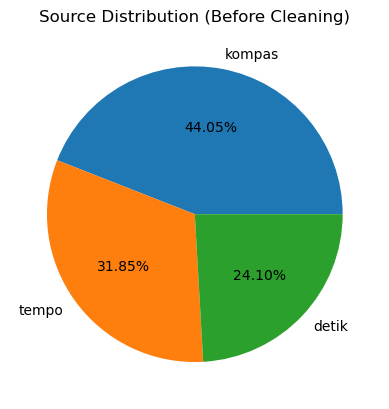

In [121]:
plot_pie("Source Distribution (Before Cleaning)", label_counts.values.tolist(), list(label_counts.keys()))

Let's remove missing and duplicate data

In [122]:
data = df.dropna()

In [123]:
data = df.drop_duplicates()

In [124]:
data.isna().sum()

Judul          0
Waktu          0
Link           0
Content        3
tag1        2442
tag2        2656
tag3        6958
tag4       17576
tag5       35117
source         0
dtype: int64

In [125]:
data.duplicated().sum()

0

In [126]:
data = data.drop(columns=['tag1', 'tag2', 'tag3', 'tag4', 'tag5', 'Link', 'Waktu'])

In [127]:
data.isnull().sum()

Judul      0
Content    3
source     0
dtype: int64

In [128]:
data[data["Content"].isna()]

,Judul,Content,source
14572,Ragam Keseruan West Java Festival 2024,NaN,detik
41018,"Video: Puncak Arus Mudik, Rest Area Km 57 Tol ...",NaN,detik
42890,Berita Ini Dicabut,NaN,detik


In [129]:
data = data.dropna(subset=["Content"])

In [130]:
data.isna().sum()

Judul      0
Content    0
source     0
dtype: int64

In [131]:
cleaned_label_counts = data['source'].value_counts()

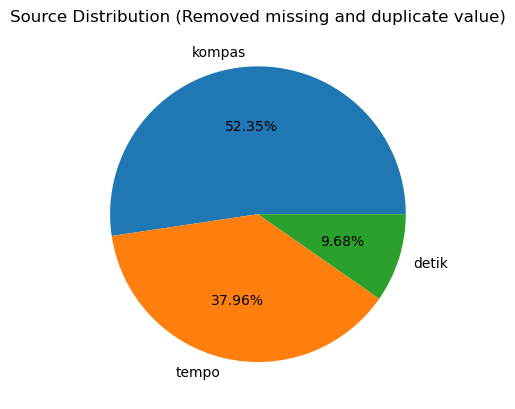

In [132]:
plot_pie("Source Distribution (Removed missing and duplicate value)", cleaned_label_counts.values.tolist(), list(cleaned_label_counts.keys()))

In [133]:
print(f"Number of rows (after dropping duplicated and missings): {len(data)}")

Number of rows (after dropping duplicated and missings): 67378


next, let's check of length Judul

In [134]:
data['judul_length'] = [len(t) for t in data['Judul'].values.tolist()]

In [135]:
data.head()

,Judul,Content,source,judul_length
0,"Viral Isu PHK Buruh Gudang Garam, Said Iqbal: ...","JAKARTA, KOMPAS.com – Presiden Konfederasi Se...",kompas,98
1,"Gempa M 5,3 Guncang Pulau Doi Maluku Utara","Gempa bumi berkekuatan magnitudo (M) 5,3 mengg...",detik,42
2,"Toko Emas Palsu di Riau Dibongkar Polisi, Perh...",Satreskrim Polres Bengkalis membongkar praktik...,detik,65
3,Minyakita Tak Sesuai Ukuran juga Ditemukan di ...,Polisi mendatangi salah satu gudang Minyakita ...,detik,72
4,"Pimpin LDP, Sanae Takaichi Calon Kuat PM Perem...","Baca berita dengan sedikit iklan, klik di sin...",tempo,65


In [136]:
avg_length = sum(data['judul_length'].values.tolist()) / len(data)
print(f'Average Judul Length: {avg_length:.2f} chars')

Average Judul Length: 69.54 chars


In [137]:
above_avg_length = sum(lt > avg_length for lt in data['judul_length'].values.tolist())
below_avg_length = sum(lt < avg_length for lt in data['judul_length'].values.tolist())

In [138]:
print(f"Judul that has a length above the average: {above_avg_length}")
print(f"Judul that has a length below the average: {below_avg_length}")

Judul that has a length above the average: 34249
Judul that has a length below the average: 33129


In [139]:
def plot_histo(title: str, values, xlabel, ylabel):
    fig, ax = plt.subplots()
    plt.title(title)
    ax.hist(values)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

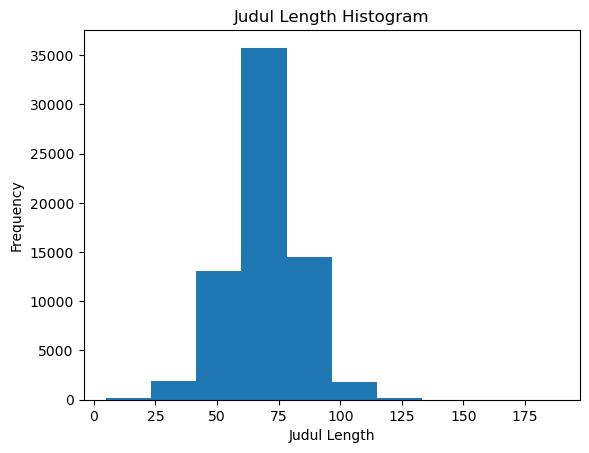

In [140]:
plot_histo("Judul Length Histogram", data['judul_length'].values.tolist(), "Judul Length", "Frequency")

next, let's check of length Content

In [141]:
data['content_length'] = [len(t) for t in data['Content'].values.tolist()]

In [142]:
data.head()

,Judul,Content,source,judul_length,content_length
0,"Viral Isu PHK Buruh Gudang Garam, Said Iqbal: ...","JAKARTA, KOMPAS.com – Presiden Konfederasi Se...",kompas,98,2283
1,"Gempa M 5,3 Guncang Pulau Doi Maluku Utara","Gempa bumi berkekuatan magnitudo (M) 5,3 mengg...",detik,42,808
2,"Toko Emas Palsu di Riau Dibongkar Polisi, Perh...",Satreskrim Polres Bengkalis membongkar praktik...,detik,65,2443
3,Minyakita Tak Sesuai Ukuran juga Ditemukan di ...,Polisi mendatangi salah satu gudang Minyakita ...,detik,72,1844
4,"Pimpin LDP, Sanae Takaichi Calon Kuat PM Perem...","Baca berita dengan sedikit iklan, klik di sin...",tempo,65,2679


In [143]:
avg_length = sum(data['content_length'].values.tolist()) / len(data)
print(f'Average Content Length: {avg_length:.2f} chars')

Average Content Length: 2406.56 chars


In [144]:
above_avg_length = sum(lt > avg_length for lt in data['content_length'].values.tolist())
below_avg_length = sum(lt < avg_length for lt in data['content_length'].values.tolist())

In [145]:
print(f"Content that has a length above the average: {above_avg_length}")
print(f"Content that has a length below the average: {below_avg_length}")

Content that has a length above the average: 28409
Content that has a length below the average: 38969


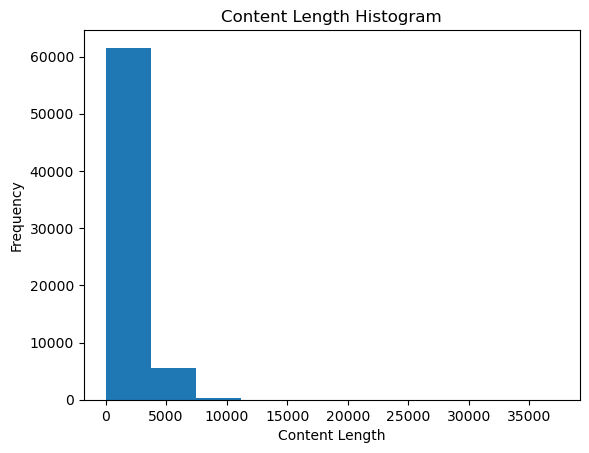

In [146]:
plot_histo("Content Length Histogram", data['content_length'].values.tolist(), "Content Length", "Frequency")